In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the data
df = pd.read_csv('data/netflix_shows_clean.csv')

In [3]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

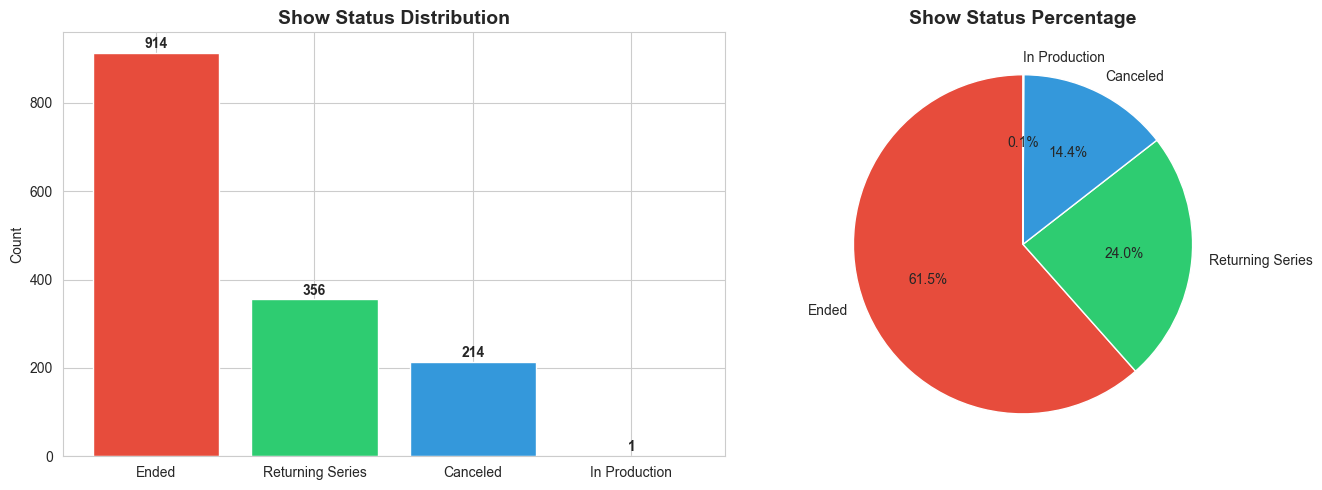

In [4]:
# Status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
status_counts = df['status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color=['#e74c3c', '#2ecc71', '#3498db'])
axes[0].set_title('Show Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Percentage
status_pct = (status_counts / len(df)) * 100
axes[1].pie(status_pct.values, labels=status_pct.index, autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71', '#3498db'], startangle=90)
axes[1].set_title('Show Status Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/01_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print(f"Cancellation rate: {status_pct['Canceled']:.2f}%")

Cancellation rate: 14.41%


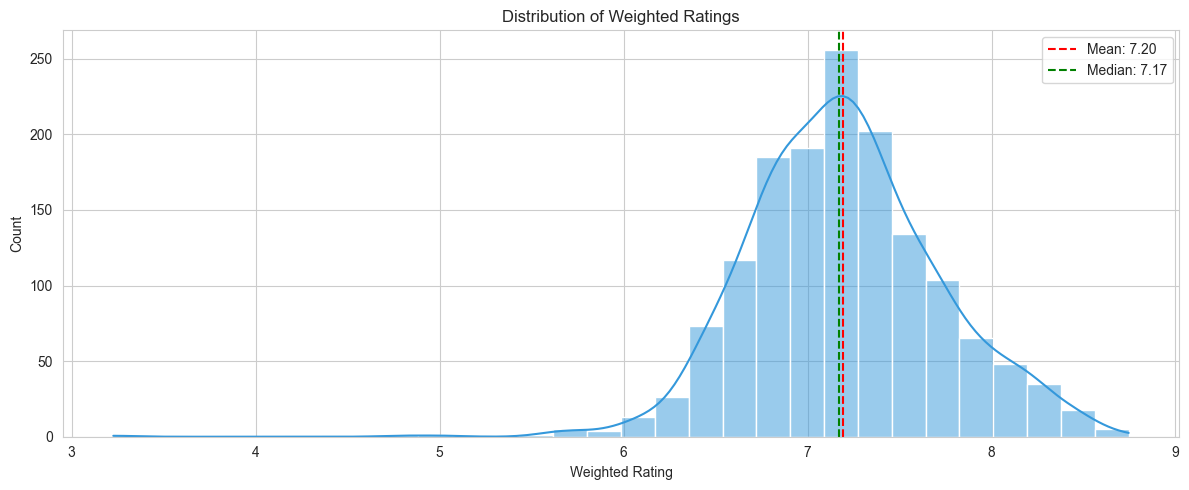

In [6]:
# Rating distribution
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='weighted_rating', bins=30, kde=True, color='#3498db')
plt.axvline(df['weighted_rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['weighted_rating'].mean():.2f}")
plt.axvline(df['weighted_rating'].median(), color='green', linestyle='--', label=f"Median: {df['weighted_rating'].median():.2f}")

plt.title('Distribution of Weighted Ratings')
plt.xlabel('Weighted Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/02_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Create binary target: 1 = Canceled, 0 = everything else
df['is_canceled'] = (df['status'] == 'Canceled').astype(int)

In [8]:
# Numeric features to compare
features = ['weighted_rating', 'popularity', 'num_seasons', 'num_episodes',
            'years_since_premiere', 'genre_count', 'vote_count']

In [9]:
# Mean value of each feature for canceled vs non-canceled shows
comparison = df.groupby('is_canceled')[features].mean().T
comparison.columns = ['Not Canceled', 'Canceled']
comparison['difference_%'] = ((comparison['Canceled'] - comparison['Not Canceled'])
                              / comparison['Not Canceled'] * 100).round(1)
print(comparison)

                      Not Canceled    Canceled  difference_%
weighted_rating           7.213547    7.086491          -1.8
popularity                6.635694    5.545529         -16.4
num_seasons               2.012589    1.644860         -18.3
num_episodes             25.320220   15.453271         -39.0
years_since_premiere      4.387194    5.364704          22.3
genre_count               2.070024    2.098131           1.4
vote_count              329.980330  348.780374           5.7


#### Cancellation Factor Analysis
- num_episodes: Canceled shows have 39% fewer episodes
- weighted_rating: Canceled shows rated 2% lower
- num_seasons: Canceled shows have 18% fewer seasons
- popularity: Canceled shows 16% less popular
- years_since_premiere: Canceled shows are 22% older on average
- genre_count: Nearly identical
- vote_count: Slightly higher for canceled (more engagement)

In [10]:
# Step 3: Cancellation rate by genre
from collections import Counter

# Each show can have multiple genres - break them into individual rows
genre_rows = []
for _, row in df.iterrows():
    if pd.notna(row['genres']) and row['genres'] != 'Unknown':
        for genre in str(row['genres']).split(','):
            genre_rows.append({'genre': genre.strip(), 'is_canceled': row['is_canceled']})

genre_df = pd.DataFrame(genre_rows)


In [11]:
# Only include genres with at least 30 shows
genre_stats = genre_df.groupby('genre').agg(
    total=('is_canceled', 'count'),
    canceled_shows=('is_canceled', 'sum')
).query('total >= 30')
genre_stats['cancel_rate_%'] = (genre_stats['canceled_shows'] / genre_stats['total'] * 100).round(1)
genre_stats = genre_stats.sort_values('cancel_rate_%', ascending=False)

print(genre_stats)

                    total  canceled_shows  cancel_rate_%
genre                                                   
Sci-Fi & Fantasy      256              58           22.7
Comedy                399              87           21.8
Family                 98              17           17.3
Action & Adventure    252              39           15.5
Drama                 787             117           14.9
Reality               113              14           12.4
Kids                  130              16           12.3
Mystery               227              26           11.5
Animation             282              29           10.3
Crime                 294              27            9.2
War & Politics         31               2            6.5
Documentary           180               8            4.4


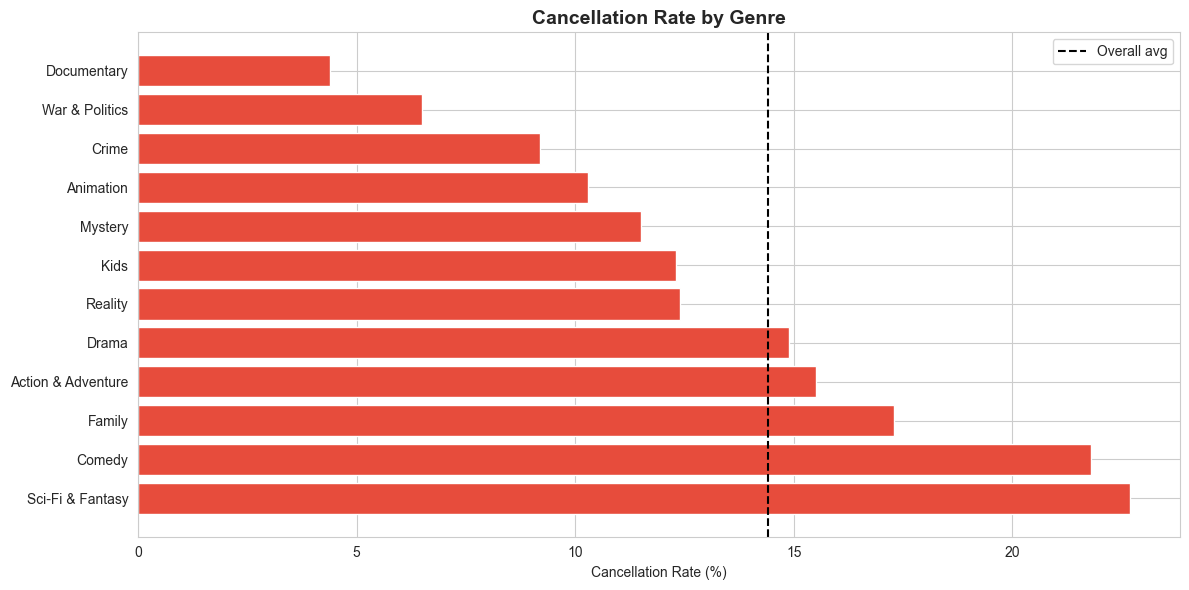

In [12]:
# Visualize
plt.figure(figsize=(12, 6))
plt.barh(genre_stats.index, genre_stats['cancel_rate_%'], color='#e74c3c')
plt.axvline(df['is_canceled'].mean() * 100, color='black', linestyle='--', label='Overall avg')
plt.xlabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Genre', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/03_genre_cancellation.png', dpi=300, bbox_inches='tight')
plt.show()

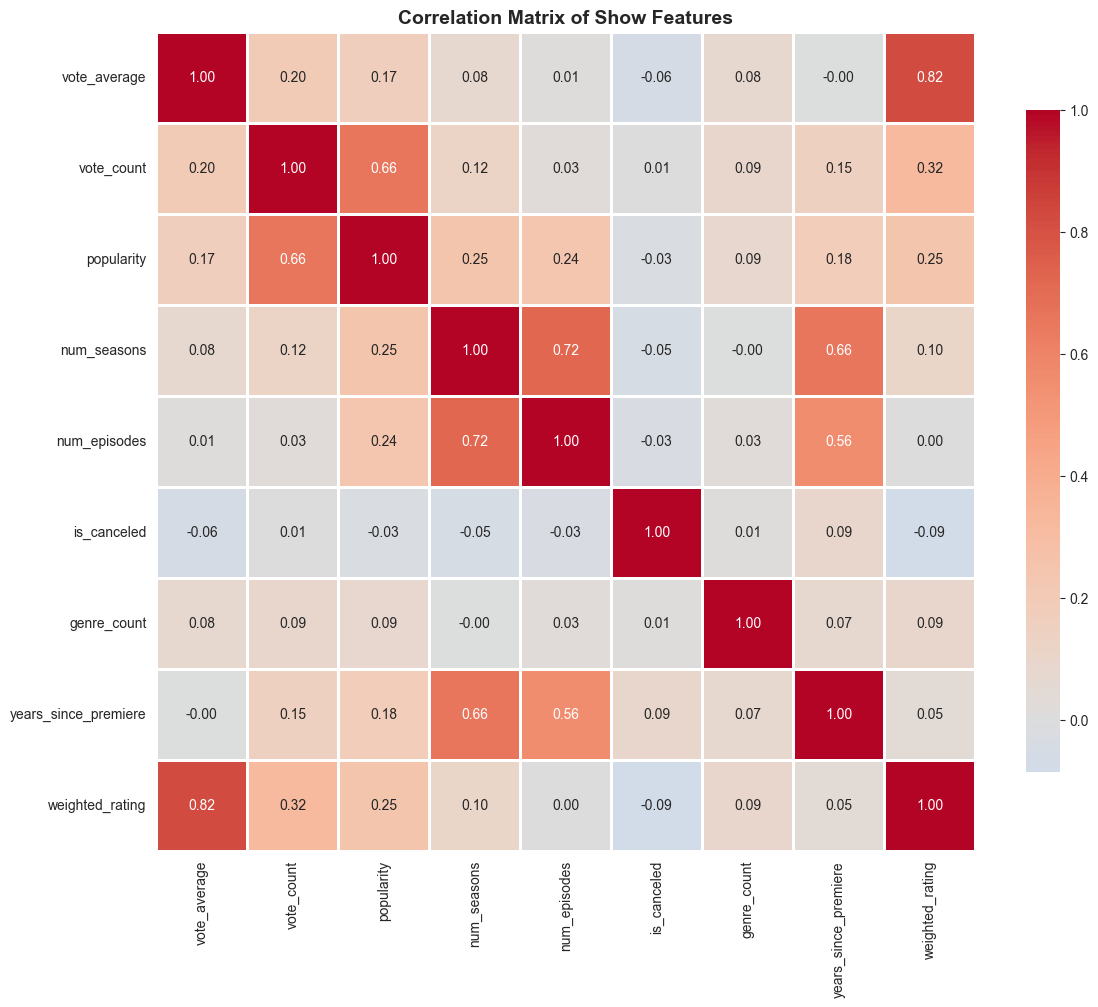


Correlations with Cancellation:
is_canceled             1.000000
years_since_premiere    0.093075
genre_count             0.009822
vote_count              0.005439
popularity             -0.027739
num_episodes           -0.031506
num_seasons            -0.050742
vote_average           -0.055777
weighted_rating        -0.085650
Name: is_canceled, dtype: float64


In [13]:
# Select numeric columns for correlation
numeric_cols = ['vote_average', 'vote_count', 'popularity', 
                'num_seasons', 'num_episodes', 'is_canceled',
                'genre_count', 'years_since_premiere', 'weighted_rating']
# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Show Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Focus on is_canceled correlations
cancellation_corr = correlation_matrix['is_canceled'].sort_values(ascending=False)
print("\nCorrelations with Cancellation:")
print(cancellation_corr)

In [14]:
# Create comparison table
summary_stats = df.groupby('status').agg({
    'vote_average': ['mean', 'median'],
    'num_seasons': ['mean', 'median'],
    'num_episodes': ['mean', 'median'],
    'popularity': ['mean', 'median'],
    'vote_count': ['mean', 'median'],
    'weighted_rating': ['mean', 'median']
}).round(2)

print("SUMMARY STATISTICS BY STATUS:")
print(summary_stats)

SUMMARY STATISTICS BY STATUS:
                 vote_average        num_seasons        num_episodes         \
                         mean median        mean median         mean median   
status                                                                        
Canceled                 7.01    7.1        1.64    1.0        15.45   10.0   
Ended                    7.16    7.2        1.69    1.0        17.23    8.0   
In Production            0.00    0.0        3.00    3.0        44.00   44.0   
Returning Series         7.15    7.2        2.85    2.0        46.03   16.0   

                 popularity        vote_count        weighted_rating         
                       mean median       mean median            mean median  
status                                                                       
Canceled               5.55   3.92     348.78  139.0            7.09   7.11  
Ended                  6.47   3.49     373.76   77.5            7.22   7.19  
In Production          5.6

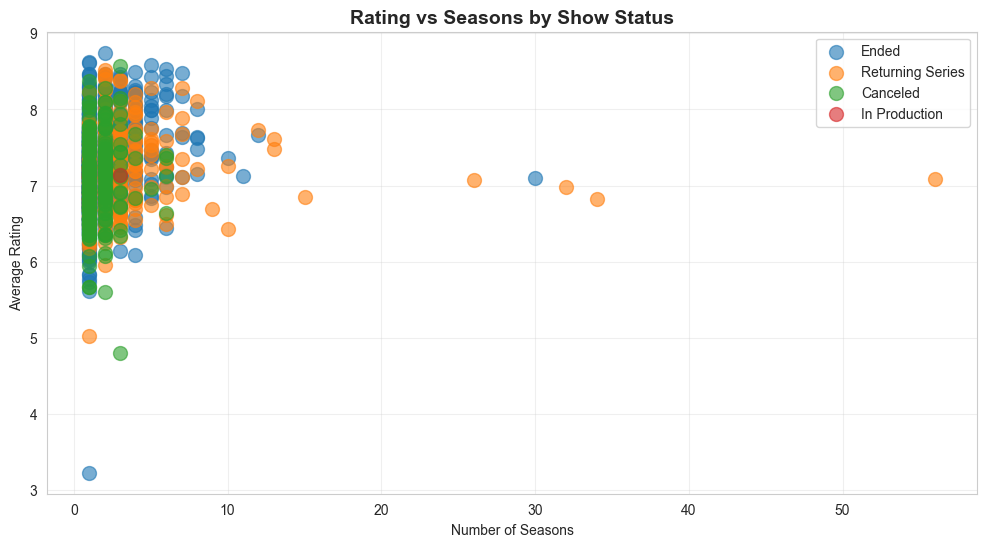

In [15]:
# Scatter plot: Rating vs Seasons, colored by status
plt.figure(figsize=(12, 6))
for status in df['status'].unique():
    data = df[df['status'] == status]
    plt.scatter(data['num_seasons'], data['weighted_rating'], 
                alpha=0.6, s=100, label=status)

plt.xlabel('Number of Seasons')
plt.ylabel('Average Rating')
plt.title('Rating vs Seasons by Show Status', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('visualizations/05_rating_vs_seasons_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

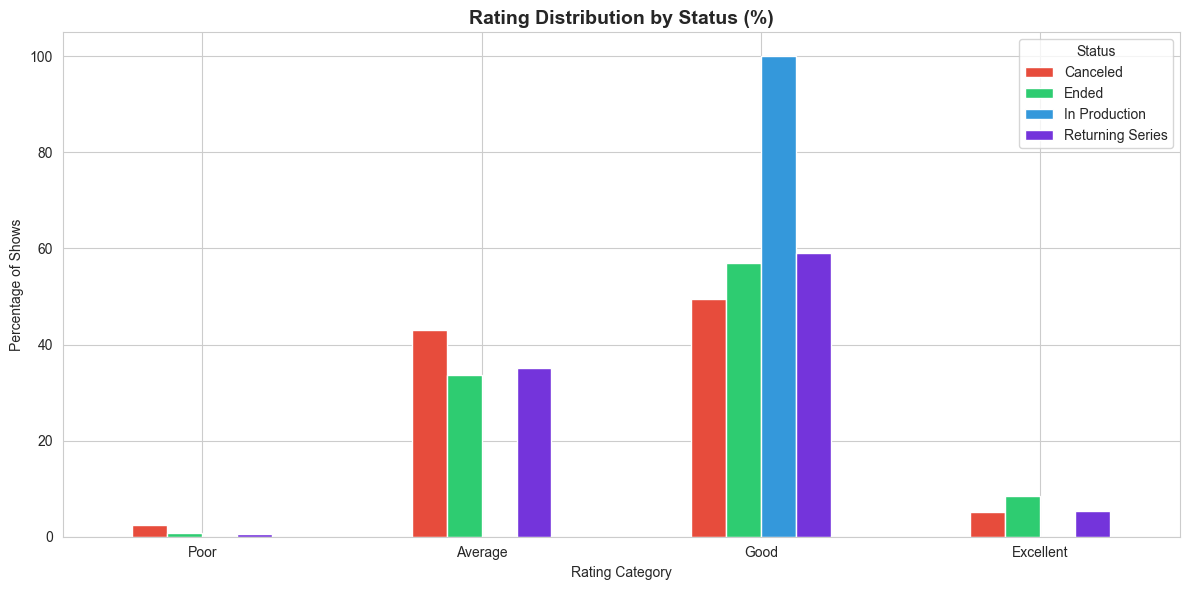

In [16]:
# Grouped bar chart: Rating categories by status
rating_status = pd.crosstab(df['rating_category'], df['status'], normalize='columns') * 100
rating_status = rating_status.loc[['Poor', 'Average', 'Good', 'Excellent']]
#print(rating_status)

rating_status.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71', '#3498db', "#7434db"])
plt.title('Rating Distribution by Status (%)', fontsize=14, fontweight='bold')
plt.xlabel('Rating Category')
plt.ylabel('Percentage of Shows')
plt.legend(title='Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visualizations/06_rating_categories_by_status.png', dpi=300, bbox_inches='tight')
plt.show()

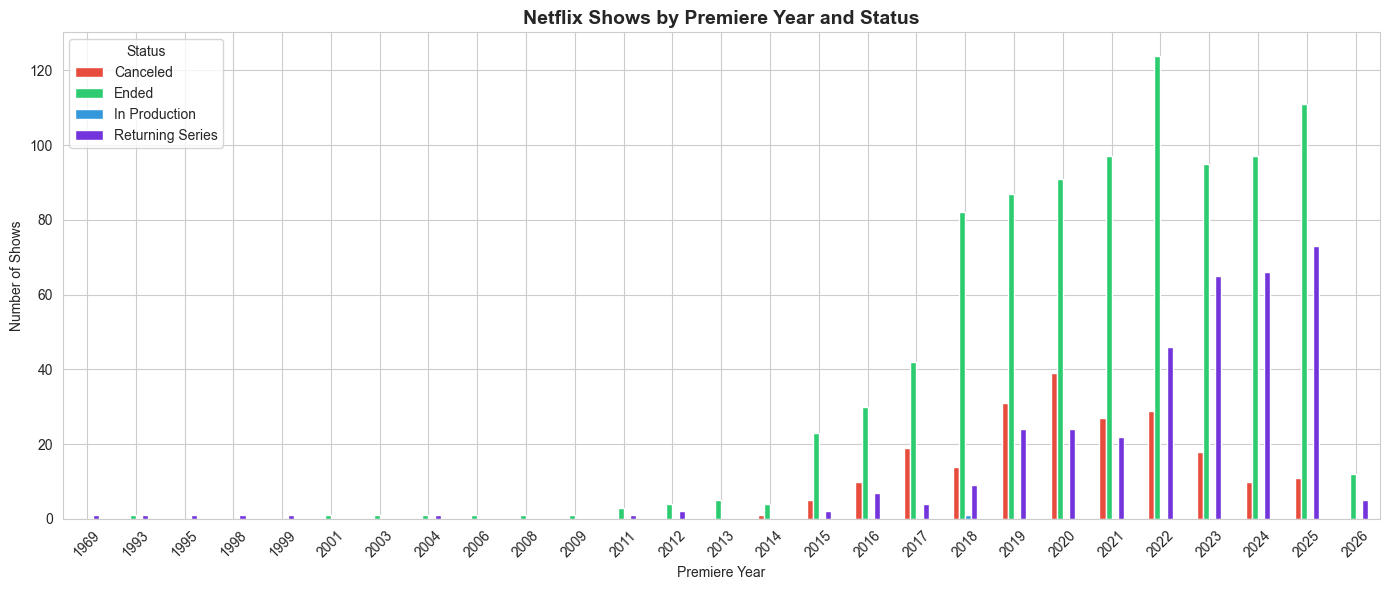

In [17]:
# Shows by premiere year and status
year_status = df.groupby(['premiere_year', 'status']).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
year_status.plot(kind='bar', stacked=False, ax=ax, 
                 color=['#e74c3c', '#2ecc71', '#3498db', "#7434db"])
plt.title('Netflix Shows by Premiere Year and Status', fontsize=14, fontweight='bold')
plt.xlabel('Premiere Year')
plt.ylabel('Number of Shows')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/07_shows_by_year_status.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_23428\223020347.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_cancellation = df.groupby('premiere_year').apply(


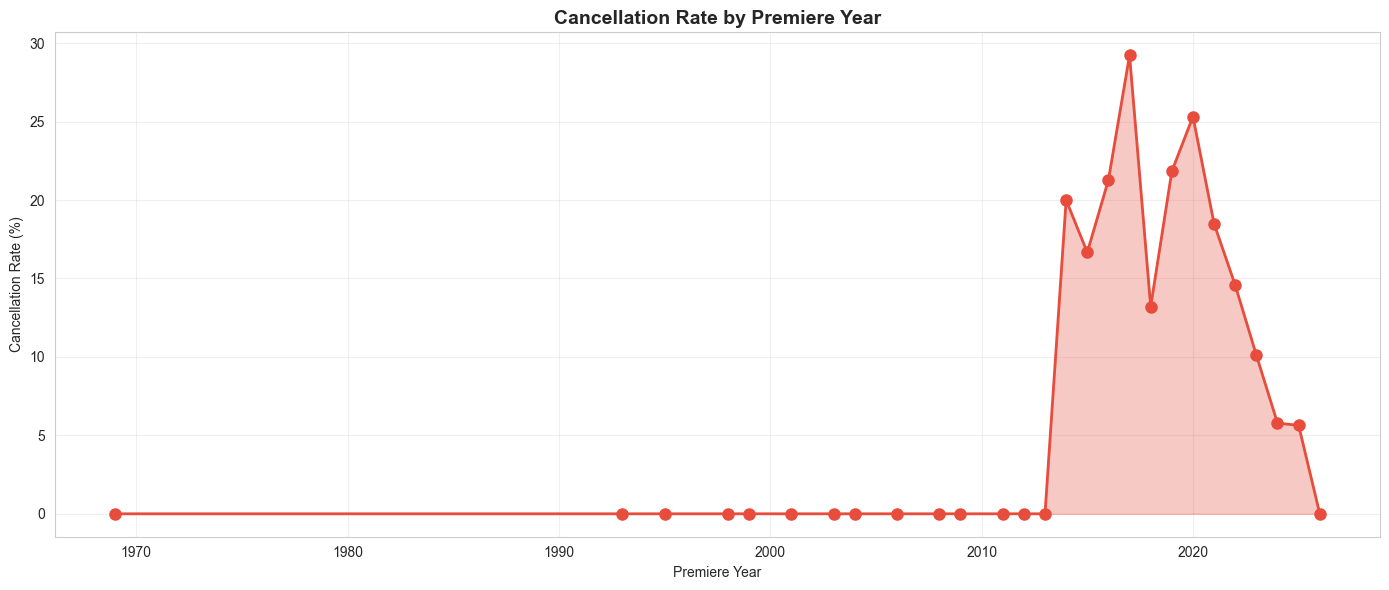

In [18]:
# Cancellation rate over time
year_cancellation = df.groupby('premiere_year').apply(
    lambda x: (x['status'] == 'Canceled').sum() / len(x) * 100
)

plt.figure(figsize=(14, 6))
plt.plot(year_cancellation.index, year_cancellation.values, 
         marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.fill_between(year_cancellation.index, year_cancellation.values, alpha=0.3, color='#e74c3c')
plt.title('Cancellation Rate by Premiere Year', fontsize=14, fontweight='bold')
plt.xlabel('Premiere Year')
plt.ylabel('Cancellation Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/08_cancellation_rate_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
from scipy import stats

# Get rating data by status
canceled_ratings = df[df['status'] == 'Canceled']['weighted_rating']
returning_ratings = df[df['status'] == 'Returning Series']['weighted_rating']

# Perform t-test
t_statistic, p_value = stats.ttest_ind(canceled_ratings, returning_ratings)

print("HYPOTHESIS TEST: Ratings Difference")
print(f"Canceled shows mean rating: {canceled_ratings.mean():.2f}")
print(f"Returning shows mean rating: {returning_ratings.mean():.2f}")
print(f"Difference: {returning_ratings.mean() - canceled_ratings.mean():.2f}")
print(f"\nT-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Result: Statistically significant difference (p < 0.05)")
    print("We can confidently say canceled shows have different ratings")
else:
    print("\n❌ Result: No statistically significant difference")

HYPOTHESIS TEST: Ratings Difference
Canceled shows mean rating: 7.09
Returning shows mean rating: 7.19
Difference: 0.10

T-statistic: -2.4005
P-value: 0.0167

✅ Result: Statistically significant difference (p < 0.05)
We can confidently say canceled shows have different ratings


In [20]:
# Test 2: Seasons difference
canceled_seasons = df[df['status'] == 'Canceled']['num_seasons']
returning_seasons = df[df['status'] == 'Returning Series']['num_seasons']

t_stat, p_val = stats.ttest_ind(canceled_seasons, returning_seasons)
print(f"\nSEASONS TEST:")
print(f"Canceled: {canceled_seasons.mean():.2f} seasons")
print(f"Returning: {returning_seasons.mean():.2f} seasons")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("\n✅ Result: Statistically significant difference (p < 0.05)")
    print("We can confidently say canceled shows have different number of seasons")
else:
    print("\n❌ Result: No statistically significant difference")


SEASONS TEST:
Canceled: 1.64 seasons
Returning: 2.85 seasons
P-value: 0.0001

✅ Result: Statistically significant difference (p < 0.05)
We can confidently say canceled shows have different number of seasons


In [21]:
# Test 3: Popularity difference
canceled_pop = df[df['status'] == 'Canceled']['popularity']
returning_pop = df[df['status'] == 'Returning Series']['popularity']

t_stat, p_val = stats.ttest_ind(canceled_pop, returning_pop)
print(f"\nPOPULARITY TEST:")
print(f"Canceled: {canceled_pop.mean():.2f}")
print(f"Returning: {returning_pop.mean():.2f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("\n✅ Result: Statistically significant difference (p < 0.05)")
    print("We can confidently say canceled shows have varying popularity")
else:
    print("\n❌ Result: No statistically significant difference")


POPULARITY TEST:
Canceled: 5.55
Returning: 7.06
P-value: 0.0453

✅ Result: Statistically significant difference (p < 0.05)
We can confidently say canceled shows have varying popularity


In [22]:
# Cohen's d for effect size
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d_rating = cohens_d(returning_ratings, canceled_ratings)
d_seasons = cohens_d(returning_seasons, canceled_seasons)

print(f"Effect size for ratings: {d_rating:.3f}")
print(f"Effect size for seasons: {d_seasons:.3f}")

Effect size for ratings: 0.208
Effect size for seasons: 0.349


In [23]:
# Interpretation
def interpret_d(d):
    if abs(d) < 0.2:
        return "Small effect"
    elif abs(d) < 0.5:
        return "Medium effect"
    else:
        return "Large effect"

print(f"Ratings: {interpret_d(d_rating)}")
print(f"Seasons: {interpret_d(d_seasons)}")

Ratings: Medium effect
Seasons: Medium effect
